In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [7]:
df = pd.read_csv('wholesome_customers_data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


| Column               | Meaning                                       |
| -------------------- | --------------------------------------------- |
| **Channel**          | Type of customer channel                      |
| **Region**           | Geographic region of the customer             |
| **Fresh**            | Annual spending on fresh products             |
| **Milk**             | Annual spending on milk products              |
| **Grocery**          | Annual spending on grocery items              |
| **Frozen**           | Annual spending on frozen products            |
| **Detergents_Paper** | Annual spending on detergents and paper goods |
| **Delicassen**       | Annual spending on delicatessen products      |


#### For Basic Data Understanding

In [9]:
df.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [10]:
df.shape


(440, 8)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [12]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


#### Check missing values:

In [13]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

#### Distribution of each feature:

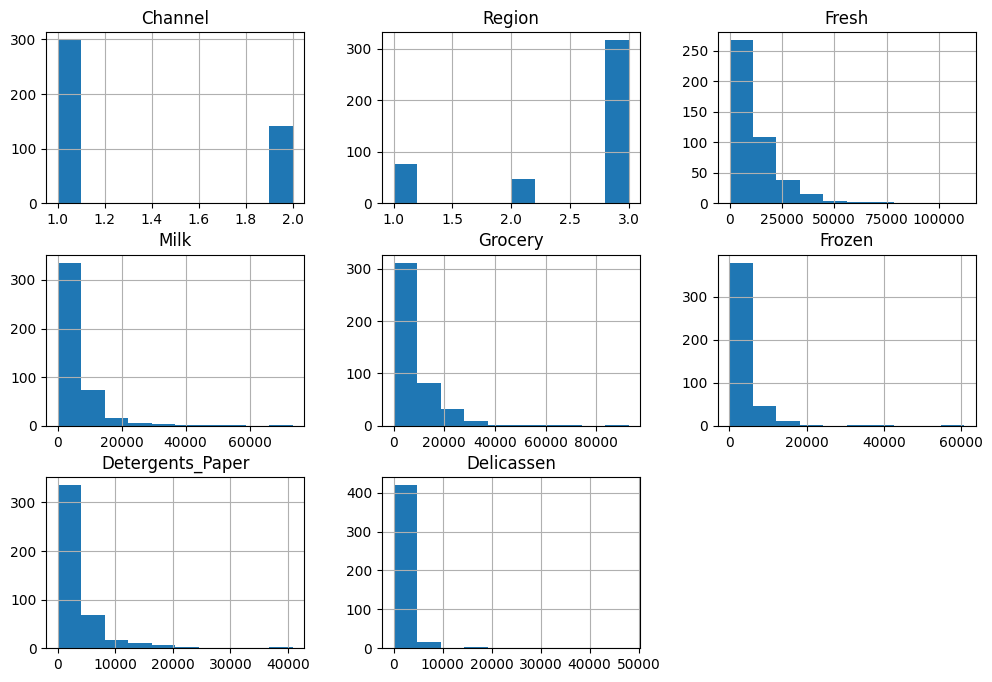

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df.hist(figsize=(12,8))
plt.show()

In [17]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


##### Channels and region counts:


Which channel has more customers?

Which region dominates the dataset?

<Axes: xlabel='Channel', ylabel='count'>

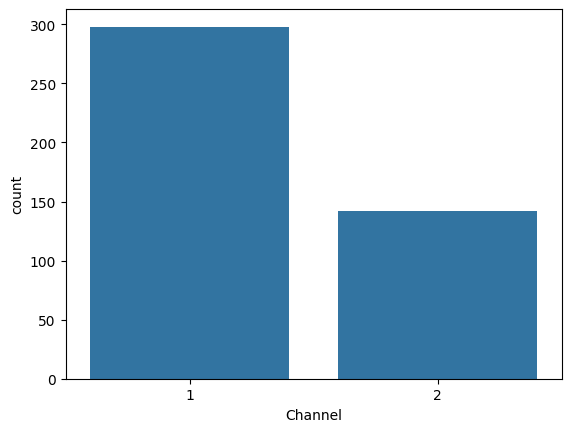

In [21]:
sns.countplot(x="Channel", data=df)


<Axes: xlabel='Region', ylabel='count'>

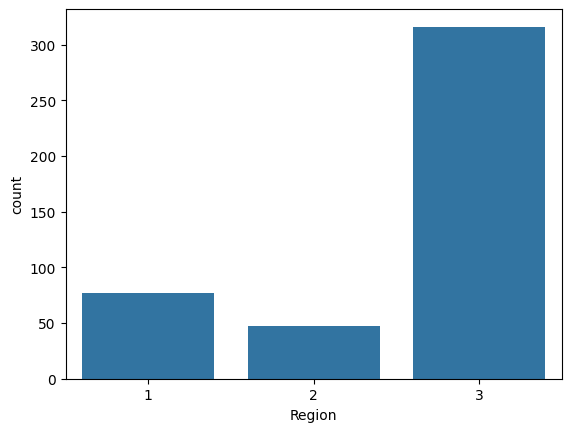

In [22]:
sns.countplot(x="Region", data=df)

##### Correlation:

<Axes: >

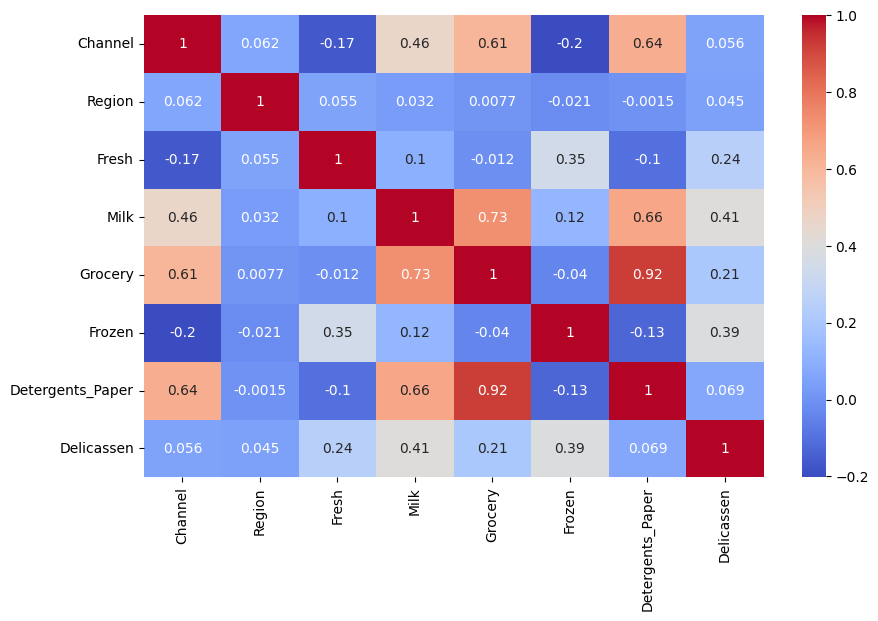

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

#### Box plot for outliers detection:

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Channel'),
  Text(1, 0, 'Region'),
  Text(2, 0, 'Fresh'),
  Text(3, 0, 'Milk'),
  Text(4, 0, 'Grocery'),
  Text(5, 0, 'Frozen'),
  Text(6, 0, 'Detergents_Paper'),
  Text(7, 0, 'Delicassen')])

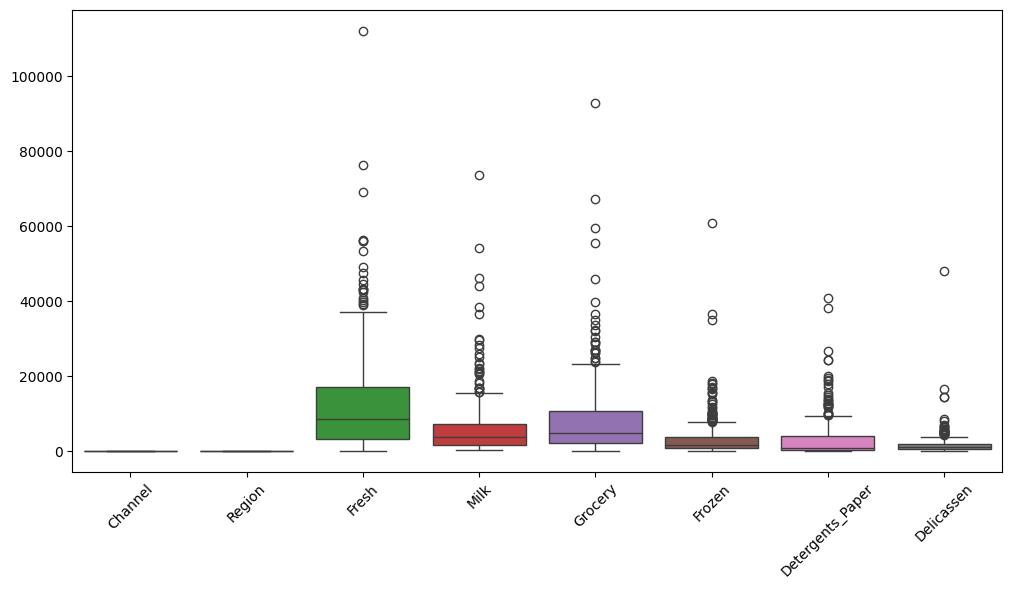

In [24]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)

####  Compare Spending by Channel

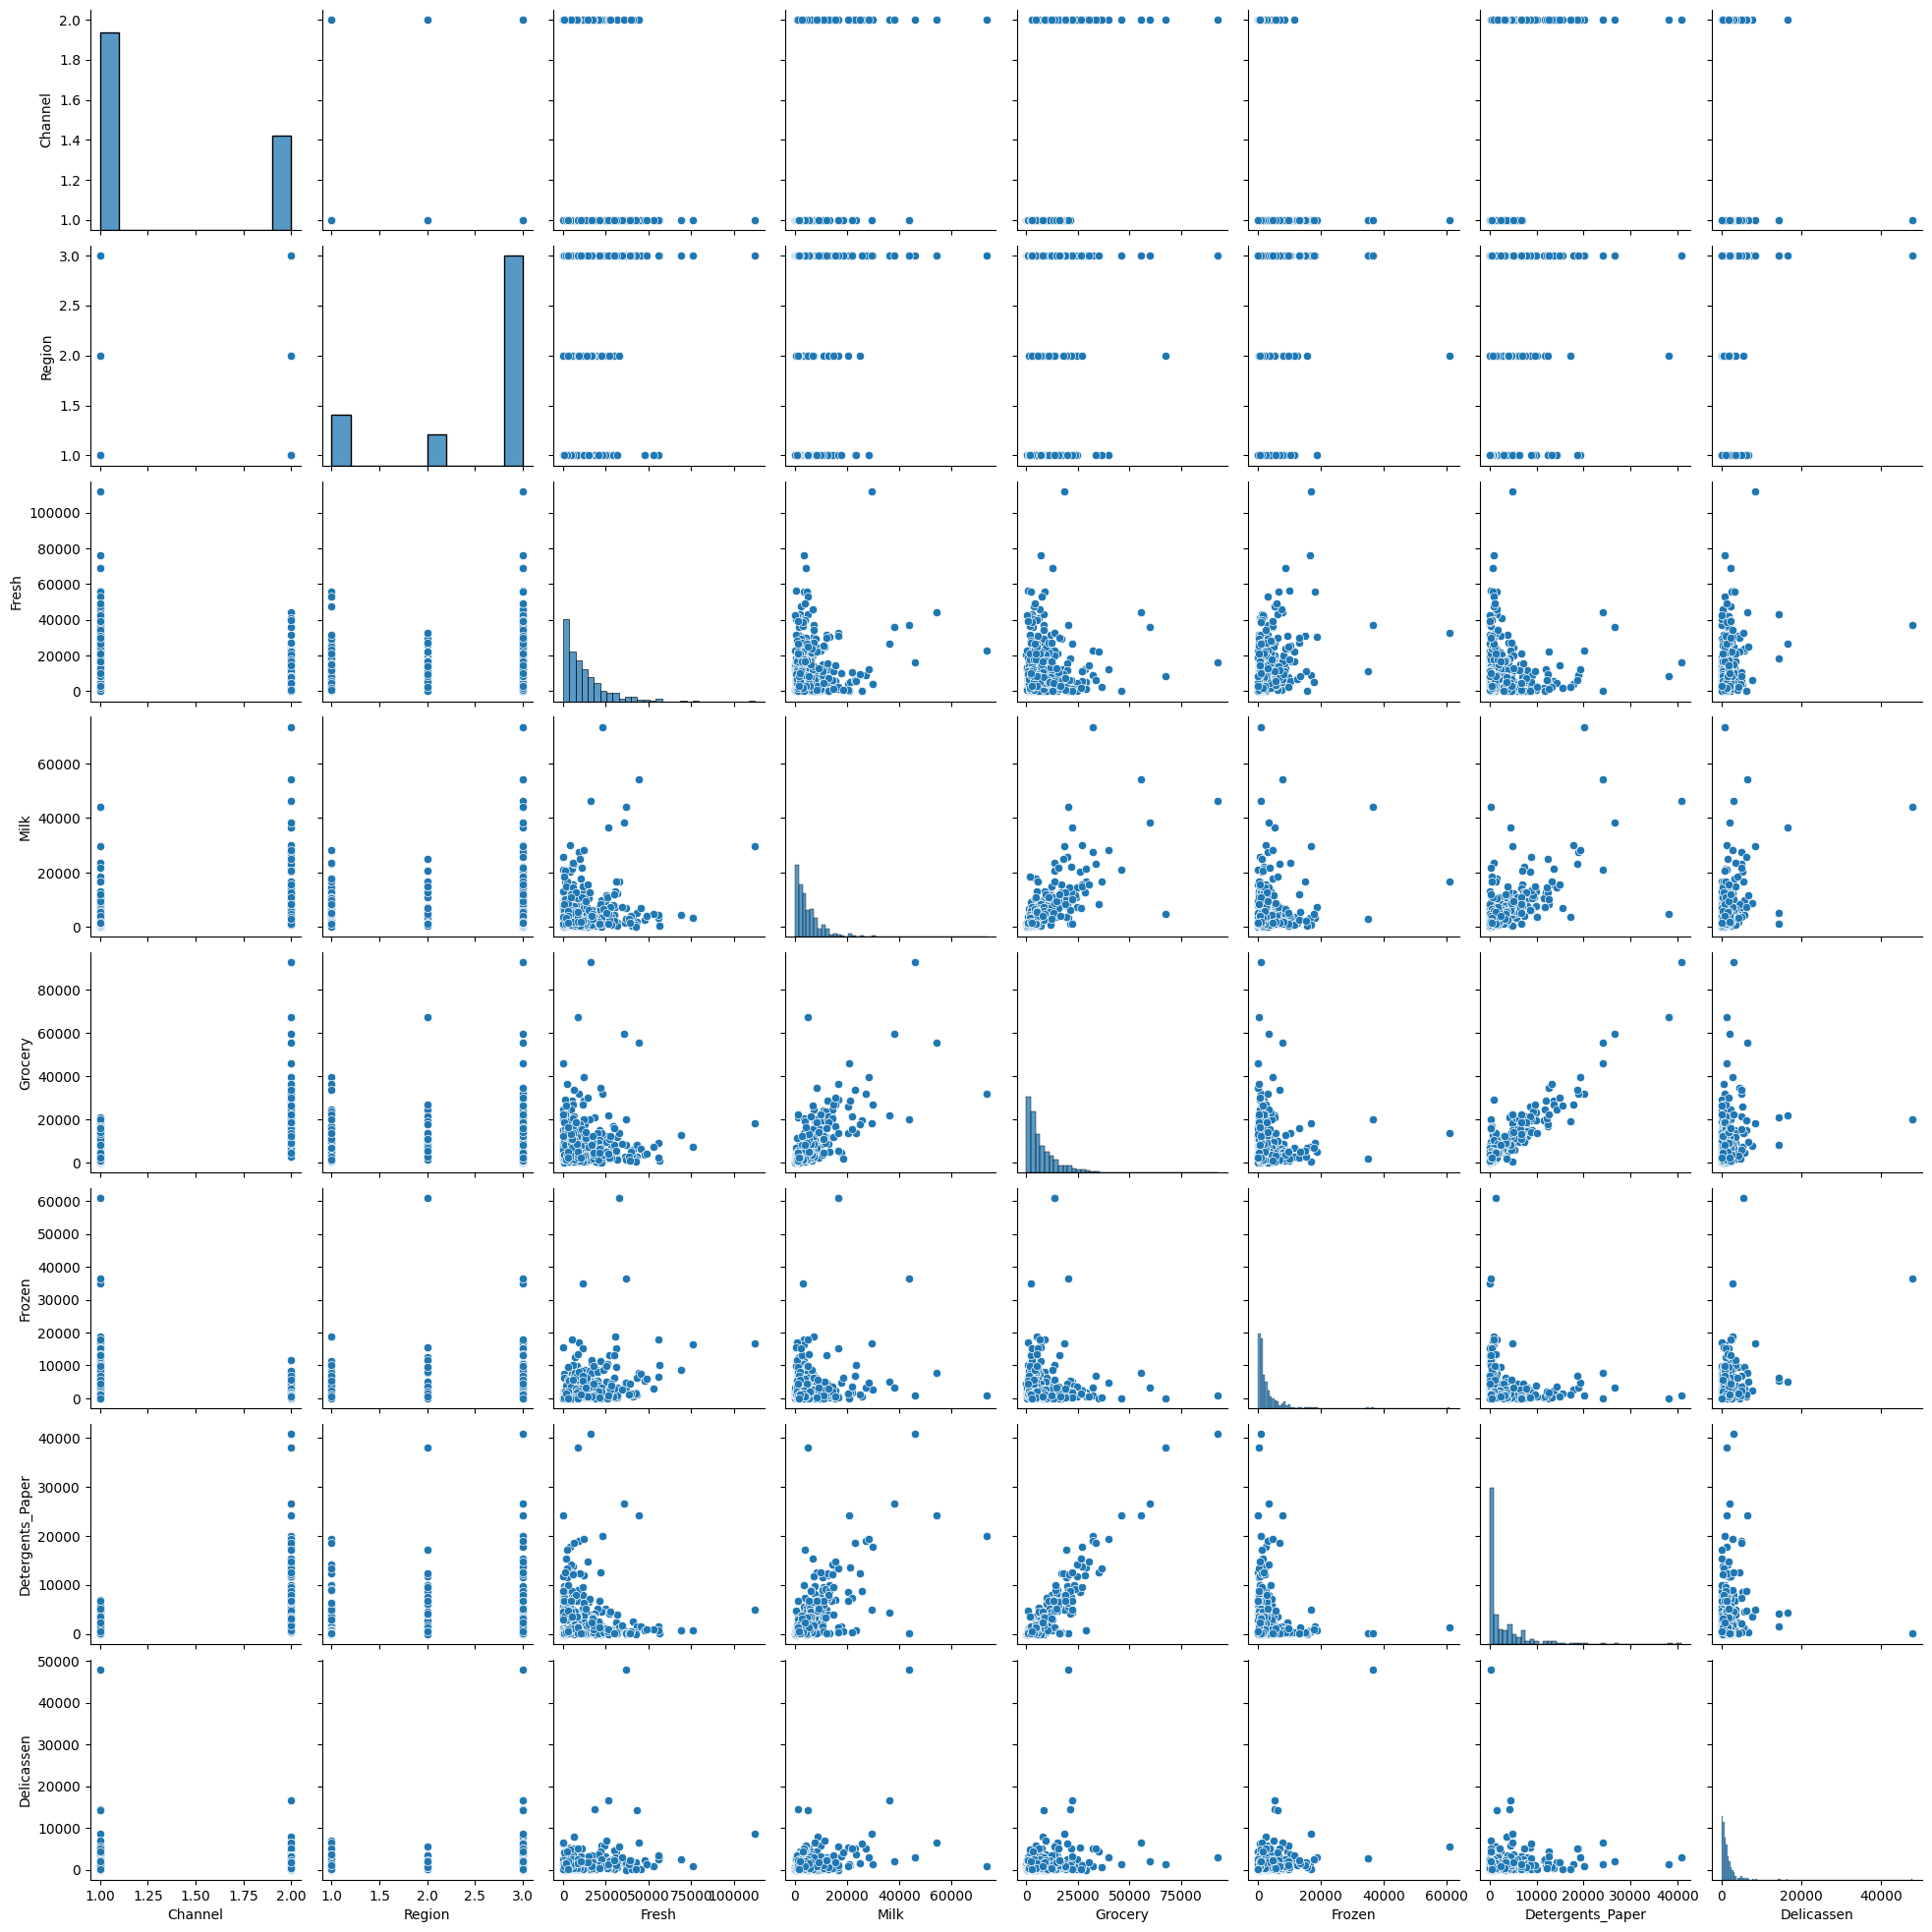

In [25]:
sns.pairplot(df)

In [26]:
df.groupby("Channel").mean()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Channel,,,,,,,
1,2.510067,13475.560403,3451.724832,3962.137584,3748.251678,790.560403,1415.956376
2,2.612676,8904.323944,10716.500000,16322.852113,1652.612676,7269.507042,1753.436620


####  ML part starts:

##### Preporcess the data 

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
sc = StandardScaler()
sc_X = sc.fit_transform(df)

In [31]:
#len(sc_X[0])

In [33]:
from sklearn.cluster import DBSCAN

In [35]:

outlier_percent = [] 

for ep in np.linspace(0.001, 3, 50):
    dbscan = DBSCAN(min_samples=2*sc_X.shape[1], eps= ep)
    dbscan.fit(sc_X)

    outlier_percent.append(100*np.sum(dbscan.labels_ == -1)/len(dbscan.labels_))

Text(0.5, 0, 'eps value')

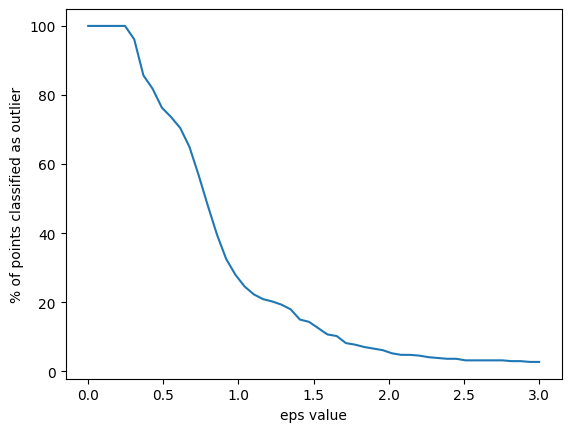

In [37]:
sns.lineplot(x= np.linspace(0.001,3, 50), y = outlier_percent)
plt.ylabel('% of points classified as outlier')
plt.xlabel('eps value')

In [39]:
dbscan_final = DBSCAN(eps = 2, min_samples=2*sc_X.shape[1])
dbscan_final.fit(sc_X)

DBSCAN(eps=2, min_samples=16)

##### scatterplot plots below shows each customer as a point.

X-axis: Grocery spending

Y-axis: Milk spending

So every point represents one customer. 

What the Plot Shows? 

The graph tells you:

Which customers form clusters

Which customers are outliers

Whether Milk and Grocery spending create natural groups

<Axes: xlabel='Grocery', ylabel='Milk'>

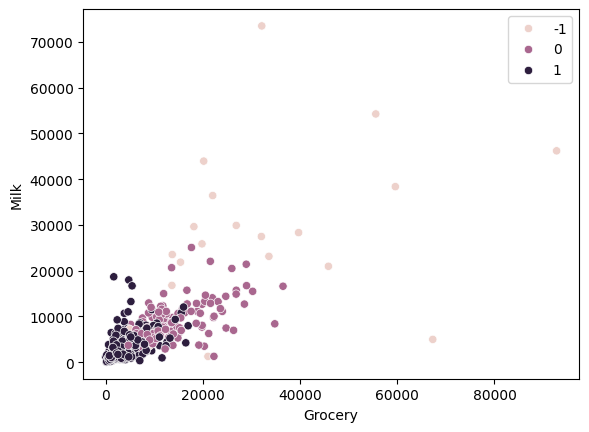

In [43]:
sns.scatterplot(data = df, x = 'Grocery', y = 'Milk', hue = dbscan_final.labels_ )